In [5]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import random
import math
from gym import Env, spaces
from math import exp

font = cv2.FONT_HERSHEY_COMPLEX_SMALL
from tqdm import tqdm
from IPython.display import clear_output

## Класс Среда

In [7]:
class ChopperScape(Env):
    def __init__(self):
        super().__init__()

        # Define a 2-D observation space
        self.observation_shape = (600, 800, 3)
        self.observation_space = spaces.Box(
            low=np.zeros(self.observation_shape),
            high=np.ones(self.observation_shape),
            dtype=np.float16,
        )

        # Create a canvas to render the environment images upon
        self.canvas = np.ones(self.observation_shape) * 1

        # Define elements present inside the environment
        self.elements = []

        self.y_min = 0
        self.x_min = 0
        self.y_max = self.observation_shape[0]
        self.x_max = self.observation_shape[1]

        self.obstacle_threshold = 1
        self.target_threshold = 10
        self.POI_threshold = 5
        self.target_x = self.observation_shape[1] - 80
        self.target_y = self.observation_shape[0] - 80
        self.max_linear = math.hypot(
            self.observation_shape[0], self.observation_shape[1]
        )

        self.choppper_init_x = 10
        self.choppper_init_y = 10
        self.exploration_field = np.zeros((600, 800))
        self.POI = None

        self.chopper = Chopper(
            "chopper", self.x_max, self.x_min, self.y_max, self.y_min
        )
        self.target = Target(
            "target", self.x_max, self.x_min, self.y_max, self.y_min
        )

        #       !!!!! ЕСЛИ МЕНЯЕШЬ ТУТ ТО ПОМЕНЯТЬ И В МАССИВЕ !!!!!
        self.first_obs = Obstacle("obs_1", 500, 300, 250, 100)
        self.elements.append(self.first_obs)
        self.exploration_field[100:250, 300:500] = 5

        self.second_obs = Obstacle("obs_2", 200, 100, 450, 300)
        self.elements.append(self.second_obs)
        self.exploration_field[300:450, 100:200] = 5

        self.third_obs = Obstacle("obs_3", 700, 550, 500, 350)
        self.elements.append(self.third_obs)
        self.exploration_field[350:500, 550:700] = 5

        self.obstacles_cord = [
            (0, -np.inf, np.inf, -np.inf),
            (np.inf, 800, np.inf, -np.inf),
            (np.inf, -np.inf, 0, -np.inf),
            (np.inf, -np.inf, np.inf, 600),  # границы поля
            (500, 300, 250, 100),
            (200, 100, 450, 300),
            (700, 550, 500, 350),
        ]  # настотящие препятствия

    def draw_elements_on_canvas(self, show_poi):
        # Init the canvas
        self.canvas = np.ones(self.observation_shape) * 1

        # Draw the heliopter on canvas
        for elem in self.elements:
            elem_shape = elem.icon.shape
            x, y = int(elem.x), int(elem.y)
            self.canvas[y : y + elem_shape[0], x : x + elem_shape[1]] = (
                elem.icon
            )

        x, y = int(self.target_x), int(self.target_y)
        elem_shape = self.target.icon.shape
        self.canvas[y : y + elem_shape[0], x : x + elem_shape[1]] = (
            self.target.icon
        )

        if show_poi:
            max_h = 0
            for draw_poi in self.chopper.POI_list:
                dist_o = math.hypot(
                    self.chopper.x - draw_poi.x, self.chopper.y - draw_poi.y
                )
                dist_g = math.hypot(
                    self.target.x - draw_poi.x, self.target.y - draw_poi.y
                )
                h_i = draw_poi.calculate_heuristic_score(
                    dist_o,
                    dist_g,
                    5,
                    20,
                    draw_poi.kernel_size,
                    self.exploration_field,
                )
                max_h = max(max_h, h_i)
            for draw_poi in self.chopper.POI_list:
                x_poi, y_poi = draw_poi.x, draw_poi.y
                top = max(0, y_poi - self.chopper.POI_area_height // 2 + 1)
                bottom = min(600, y_poi + self.chopper.POI_area_height // 2 - 1)
                left = max(0, x_poi - self.chopper.POI_area_width // 2 + 1)
                right = min(800, x_poi + self.chopper.POI_area_width // 2 - 1)
                dist_o = math.hypot(
                    self.chopper.x - draw_poi.x, self.chopper.y - draw_poi.y
                )
                dist_g = math.hypot(
                    self.target.x - draw_poi.x, self.target.y - draw_poi.y
                )
                h_i = draw_poi.calculate_heuristic_score(
                    dist_o,
                    dist_g,
                    5,
                    20,
                    draw_poi.kernel_size,
                    self.exploration_field,
                )
                self.canvas[top:bottom, left:right] = [
                    (max_h - h_i) / max_h,
                    0,
                    0,
                ]

    def reset(self):

        self.ep_return = 0

        x = self.choppper_init_x
        y = self.choppper_init_y
        alpha = 0

        # Intialise the chopper

        self.chopper.set_position(x, y, alpha)
        self.target.set_position(self.target_x, self.target_y)

        if (
            self.exploration_field[
                int(self.chopper.y) : int(self.chopper.y + self.chopper.icon_h),
                int(self.chopper.x) : int(self.chopper.x + self.chopper.icon_w),
            ]
            == 0
        ).all():
            scan = self.scan()
            self.exploration_field[
                int(self.chopper.y) : int(self.chopper.y + self.chopper.icon_h),
                int(self.chopper.x) : int(self.chopper.x + self.chopper.icon_w),
            ] = 1
            self.chopper.set_POI(scan, self.exploration_field)

        self.POI = self.chopper.get_POI(self.target, self.exploration_field)
        self.closest_dist = (
            (self.chopper.x - self.target_x) ** 2
            + (self.chopper.y - self.target_y) ** 2
        ) ** 0.5

        self.elements = [
            self.chopper,
            self.first_obs,
            self.second_obs,
            self.third_obs,
        ]

        dist_to_poi = (
            (self.chopper.x - self.POI.x) ** 2
            + (self.chopper.y - self.POI.y) ** 2
        ) ** 0.5
        rel_dis_x = self.POI.x - self.chopper.x
        rel_dis_y = self.POI.y - self.chopper.y
        rel_theta = math.atan2(rel_dis_y, rel_dis_x) % (2 * np.pi)

        diff_angle = abs(rel_theta - self.chopper.alpha)
        if diff_angle > np.pi:
            diff_angle = 2 * np.pi - diff_angle

        scans = self.scan()
        return (
            scans
            + [rel_theta / (2 * np.pi), diff_angle / np.pi]
            + [dist_to_poi / self.max_linear]
        )

    def render(self, show_poi=False):

        self.draw_elements_on_canvas(show_poi)
        # assert mode in ["human", "rgb_array"], "Invalid mode, must be either \"human\" or \"rgb_array\""
        # if mode == "human":
        plt.imshow(self.canvas)
        plt.show()

        # elif mode == "rgb_array":
        # return self.canvas

    def scan(self):
        scan_result = []
        # x_0, y_0 = self.chopper.x, self.chopper.y
        x_0, y_0 = (
            self.chopper.x + self.chopper.icon_w // 2,
            self.chopper.y + self.chopper.icon_h // 2,
        )
        for detector_alpha in self.chopper.scan_range:
            min_dist = self.max_linear
            scan_alpha = (self.chopper.alpha + detector_alpha) % (2 * np.pi)
            for x_max, x_min, y_max, y_min in self.obstacles_cord:
                if np.pi / 2 < scan_alpha < 3 * np.pi / 2:
                    if x_0 > x_max:
                        y_intersect = math.tan(scan_alpha) * (x_max - x_0) + y_0
                        if y_min < y_intersect < y_max:
                            min_dist = min(
                                min_dist,
                                math.hypot(x_0 - x_max, y_0 - y_intersect),
                            )
                elif scan_alpha != np.pi / 2 and scan_alpha != 3 * np.pi / 2:
                    if x_0 < x_min:
                        y_intersect = math.tan(scan_alpha) * (x_min - x_0) + y_0
                        if y_min < y_intersect < y_max:
                            min_dist = min(
                                min_dist,
                                math.hypot(x_0 - x_min, y_0 - y_intersect),
                            )

                if np.pi < scan_alpha < 2 * np.pi:
                    if y_0 > y_max:
                        x_intersect = (1 / math.tan(scan_alpha)) * (
                            y_max - y_0
                        ) + x_0
                        if x_min < x_intersect < x_max:
                            min_dist = min(
                                min_dist,
                                math.hypot(x_0 - x_intersect, y_0 - y_max),
                            )
                elif (
                    scan_alpha != 0
                    and scan_alpha != np.pi
                    and scan_alpha != 2 * np.pi
                ):
                    if y_0 < y_min:
                        x_intersect = (1 / math.tan(scan_alpha)) * (
                            y_min - y_0
                        ) + x_0
                        if x_min < x_intersect < x_max:
                            min_dist = min(
                                min_dist,
                                math.hypot(x_0 - x_intersect, y_0 - y_min),
                            )

            scan_result.append(min_dist / self.max_linear)

        return scan_result

    def has_collided(self, elem1, elem2, icon1_w=None, icon1_h=None):
        x_col = False
        y_col = False

        elem1_x, elem1_y = elem1.get_position()
        elem2_x, elem2_y = elem2.get_position()

        icon1_w = elem1.icon_w if icon1_w is None else icon1_w
        icon1_h = elem1.icon_h if icon1_h is None else icon1_h

        if (elem1_x >= elem2_x and elem1_x - elem2_x <= elem2.icon_w) or (
            elem1_x < elem2_x and elem2_x - elem1_x <= icon1_w
        ):
            x_col = True

        if (elem1_y >= elem2_y and elem1_y - elem2_y <= elem2.icon_h) or (
            elem1_y < elem2_y and elem2_y - elem1_y <= icon1_h
        ):
            y_col = True

        if x_col and y_col:
            return True

        return False

    def out_of_boundary(self, elem):

        elem_x, elem_y = elem.get_position()

        if (
            elem_x - self.x_min < self.obstacle_threshold
            or self.x_max - elem_x - self.chopper.icon_w
            < self.obstacle_threshold
            or elem_y - self.y_min < self.obstacle_threshold
            or self.y_max - elem_y - self.chopper.icon_h
            < self.obstacle_threshold
        ):
            return True

        return False

    def is_arrive(self):

        if (
            (self.chopper.x - self.target_x) ** 2
            + (self.chopper.y - self.target_y) ** 2
        ) ** 0.5 < self.target_threshold:
            return True

    def is_not_valid(self, target):
        for elem in self.elements:
            if isinstance(elem, Obstacle):
                if self.has_collided(target, elem, 70, 70):
                    return True
        return False

    def step(self, action):
        done = 0
        arrived = 0

        self.chopper.alpha += action[1]
        self.chopper.alpha = self.chopper.alpha % (2 * np.pi)
        self.chopper.x += (
            10 * ((action[0] + 1) / 2) * np.cos(self.chopper.alpha)
        )
        self.chopper.y += (
            10 * ((action[0] + 1) / 2) * np.sin(self.chopper.alpha)
        )

        dist_to_target = (
            (self.chopper.x - self.target.x) ** 2
            + (self.chopper.y - self.target.y) ** 2
        ) ** 0.5

        if dist_to_target < self.target_threshold:
            reward = 101
            arrived = 1
        else:
            reward = action[0] - abs(action[1])

        reward -= 1

        if self.out_of_boundary(self.chopper):
            done = 1
            reward = -50
            self.elements.remove(self.chopper)

        for elem in self.elements:
            if isinstance(elem, Obstacle):
                if self.has_collided(self.chopper, elem):
                    done = 1
                    reward = -50
                    if self.chopper in self.elements:
                        self.elements.remove(self.chopper)

        if (
            not done
            and (
                self.exploration_field[
                    int(self.chopper.y) : int(
                        self.chopper.y + self.chopper.icon_h
                    ),
                    int(self.chopper.x) : int(
                        self.chopper.x + self.chopper.icon_w
                    ),
                ]
                == 0
            ).all()
        ):
            scan = self.scan()
            self.exploration_field[
                int(self.chopper.y) : int(self.chopper.y + self.chopper.icon_h),
                int(self.chopper.x) : int(self.chopper.x + self.chopper.icon_w),
            ] = 1

            self.chopper.set_POI(scan, self.exploration_field)

        dist_to_poi = (
            (self.chopper.x - self.POI.x) ** 2
            + (self.chopper.y - self.POI.y) ** 2
        ) ** 0.5
        rel_dis_x = self.POI.x - self.chopper.x
        rel_dis_y = self.POI.y - self.chopper.y
        rel_theta = math.atan2(rel_dis_y, rel_dis_x) % (2 * np.pi)

        scans = self.scan()

        select_new_POI = False
        # for i in range(len(self.chopper.scan_range)-1):
        #     if self.chopper.scan_range[i] <= rel_theta <= self.chopper.scan_range[i+1]:
        #         if scans[i] < 0.05 and scans[i+1] < 0.05:
        #             self.chopper.POI_list.remove(self.POI)
        #             select_new_POI = True
        #             break

        if dist_to_poi < self.POI_threshold or select_new_POI:
            self.POI = self.chopper.get_POI(
                self.target, self.exploration_field, self.POI
            )
            dist_to_poi = (
                (self.chopper.x - self.POI.x) ** 2
                + (self.chopper.y - self.POI.y) ** 2
            ) ** 0.5
            rel_dis_x = self.POI.x - self.chopper.x
            rel_dis_y = self.POI.y - self.chopper.y
            rel_theta = math.atan2(rel_dis_y, rel_dis_x) % (2 * np.pi)

        if dist_to_target < 64:
            self.POI = POI(self.target.x, self.target.y)
            rel_dis_x = self.POI.x - self.chopper.x
            rel_dis_y = self.POI.y - self.chopper.y
            rel_theta = math.atan2(rel_dis_y, rel_dis_x) % (2 * np.pi)

        diff_angle = abs(rel_theta - self.chopper.alpha)
        if diff_angle > np.pi:
            diff_angle = 2 * np.pi - diff_angle

        self.ep_return += 1

        return (
            scans
            + [rel_theta / (2 * np.pi), diff_angle / np.pi]
            + [dist_to_poi / self.max_linear],
            reward,
            done,
            arrived,
        )

### Класс объекта в среде

In [8]:
class Point:
    def __init__(self, name, x_max, x_min, y_max, y_min):
        self.x = 0
        self.y = 0
        self.x_min = x_min
        self.x_max = x_max
        self.y_min = y_min
        self.y_max = y_max
        self.name = name

    def set_position(self, x, y):
        # self.x = self.clamp(x, self.x_min, self.x_max - self.icon_w)
        # self.y = self.clamp(y, self.y_min, self.y_max - self.icon_h)
        self.x = x
        self.y = y

    def get_position(self):
        return (self.x, self.y)

    def move(self, del_x, del_y):
        self.x += del_x
        self.y += del_y

        # self.x = self.clamp(self.x, self.x_min, self.x_max - self.icon_w)
        # self.y = self.clamp(self.y, self.y_min, self.y_max - self.icon_h)

    def clamp(self, n, minn, maxn):
        return max(min(maxn, n), minn)

### Класс робота

In [9]:
class Chopper(Point):
    def __init__(self, name, x_max, x_min, y_max, y_min):
        super().__init__(name, x_max, x_min, y_max, y_min)
        self.icon = cv2.imread("./helicopter.jpg") / 255.0
        self.icon_w = 32
        self.icon_h = 32
        self.icon = cv2.resize(self.icon, (self.icon_h, self.icon_w))
        self.POI_field = np.zeros((y_max - y_min, x_max - x_min), dtype=object)
        self.POI_id = 0
        self.POI_area_width = 100
        self.POI_area_height = 100
        self.POI_list = []
        self.scan_range = [i * np.pi / 6 for i in range(-3, 4)]

    def set_position(self, x, y, alpha):
        self.x = x
        self.y = y
        self.alpha = alpha

    def get_POI(self, target, field, current_poi=None):
        min_h = 10e10
        best_poi = None
        for point in self.POI_list:
            dist_o = math.hypot(self.x - point.x, self.y - point.y)
            dist_g = math.hypot(target.x - point.x, target.y - point.y)
            h_i = point.calculate_heuristic_score(
                dist_o, dist_g, 5, 20, point.kernel_size, field
            )
            if h_i < min_h and point != current_poi:
                min_h = h_i
                best_poi = point

        return best_poi

    def set_POI(self, scan, field):
        for distance, detector_angle in zip(scan, self.scan_range):
            try_dist = 0.1
            angle = detector_angle + self.alpha
            while try_dist + 0.05 < distance:
                x_poi = int(self.x + 1000 * try_dist * math.cos(angle))
                y_poi = int(self.y + 1000 * try_dist * math.sin(angle))

                top = max(0, y_poi - self.POI_area_height // 2 + 1)
                bottom = min(600, y_poi + self.POI_area_height // 2 - 1)
                left = max(0, x_poi - self.POI_area_width // 2 + 1)
                right = min(800, x_poi + self.POI_area_width // 2 - 1)

                if (self.POI_field[top:bottom, left:right] == 0).all():
                    new_POI = POI(x_poi, y_poi)

                    self.POI_field[top:bottom, left:right] = 1
                    self.POI_list.append(new_POI)

                try_dist += 0.1


class POI:
    def __init__(self, x, y):

        # self.icon = cv2.imread("/content/drive/MyDrive/Colab_Notebooks/RL/Курсовая/border.png") / 255.0
        self.icon_w = 98
        self.icon_h = 98
        # self.icon = cv2.resize(self.icon, (self.icon_w, self.icon_h))
        self.x = x
        self.y = y
        self.kernel_size = 100

    def count_information(self, field, kernel_size):
        left = max(0, self.x - int(kernel_size / 2))
        right = min(len(field[0]), self.x + int(kernel_size / 2))
        top = max(0, self.y - int(kernel_size / 2))
        bottom = min(len(field), self.y + int(kernel_size / 2))
        point_information = np.sum(field[top:bottom, left:right])
        count = (right - left) * (bottom - top)
        I = exp(point_information / count)
        return I

    def calculate_heuristic_score(
        self, dist_o, dist_g, dist_l1, dist_l2, kernel_size, field
    ):
        dist_o = dist_o / 20
        dist_g = dist_g / 20
        d1 = (
            np.tanh(
                np.exp((dist_o / dist_l1) ** 2) / exp((dist_l2 / dist_l1) ** 2)
            )
            * dist_l2
        )
        d2 = dist_g
        I = self.count_information(field, kernel_size)
        return d1 + d2 + I

In [ ]:
# удалять при приближении
# корректонсть лидара ти учитывать ширину и длину
# сделать чтобы пои сменялась на таргет


class Obstacle(Point):
    def __init__(self, name, x_max, x_min, y_max, y_min):
        super().__init__(name, x_max, x_min, y_max, y_min)
        self.icon = cv2.imread("./border.png") / 255.0
        self.icon_w = x_max - x_min
        self.icon_h = y_max - y_min
        self.x = x_min
        self.y = y_min
        self.icon = cv2.resize(self.icon, (self.icon_w, self.icon_h))


class Target(Point):
    def __init__(self, name, x_max, x_min, y_max, y_min):
        super().__init__(name, x_max, x_min, y_max, y_min)
        self.icon = cv2.imread("./border.png") / 255.0
        self.icon_w = 16
        self.icon_h = 16
        self.icon = cv2.resize(self.icon, (self.icon_w, self.icon_h))

### Алгоритм Q-learning
### Нейросети Actor и Critic

In [16]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
import torch.nn as nn
import torch.nn.functional as F


class Actor(nn.Module):
    def __init__(self, state_size, action_size):
        super().__init__()
        self.state_size = state_size
        self.action_size = action_size
        self.linear1 = nn.Linear(self.state_size, 128)
        self.linear2 = nn.Linear(128, 256)
        self.linear3 = nn.Linear(256, self.action_size)

    def forward(self, state):
        x = F.relu(self.linear1(state))
        x = F.relu(self.linear2(x))
        value = F.tanh(self.linear3(x))
        return value


class Critic(nn.Module):
    def __init__(self, input_size, output_size):
        super().__init__()
        self.linear1 = nn.Linear(input_size, 128)
        self.linear2 = nn.Linear(128, 256)
        self.linear3 = nn.Linear(256, output_size)

    def forward(self, input):
        x = F.relu(self.linear1(input))
        x = F.relu(self.linear2(x))
        value = self.linear3(x)
        return value

### Процесс обучения

In [ ]:
def update_target_network(target_network, source_network, tau):
    for target_param, param in zip(
        target_network.parameters(), source_network.parameters()
    ):
        target_param.data.copy_(
            target_param.data * (1.0 - tau) + param.data * tau
        )


def train_policy(
    num_episodes: int = 100,
    gamma: float = 0.99,
    tau: float = 0.0005,
    buffer_size: int = 10000,
    batch_size: int = 64,
):

    actor = Actor(10, 2).to(device)
    critic = Critic(12, 1).to(device)
    actor_target = Actor(10, 2).to(device)
    critic_target = Critic(12, 1).to(device)
    update_target_network(actor_target, actor, 1)
    update_target_network(critic_target, critic, 1)

    actor_optimizer = torch.optim.Adam(actor.parameters(), lr=0.001)
    critic_optimizer = torch.optim.Adam(critic.parameters(), lr=0.005)

    env = ChopperScape()
    replay_buffer = []

    def add_to_replay_buffer(state, action, reward, next_state, done):
        replay_buffer.append((state, action, reward, next_state, done))
        if len(replay_buffer) > buffer_size:
            replay_buffer.pop(0)

    def sample_from_replay_buffer():
        return zip(*random.sample(replay_buffer, batch_size))

    for episode in range(num_episodes):
        state = torch.FloatTensor(env.reset()).reshape(1, -1).to(device)
        episode_reward = 0
        for time_step in range(500):
            if torch.rand(1).item() > 0.1:
                with torch.no_grad():
                    action = actor(state)
            else:
                action = (2 * torch.rand((1, 2)) - 1).to(device)

            next_state, reward, done, arrived = env.step(
                action.detach().cpu().numpy().reshape(-1)
            )
            next_state = torch.FloatTensor(next_state).reshape(1, -1).to(device)
            reward = torch.FloatTensor([reward]).reshape(1, 1).to(device)
            done = torch.FloatTensor([done]).reshape(1, 1).to(device)
            add_to_replay_buffer(state, action, reward, next_state, done)

            if len(replay_buffer) >= batch_size:
                states, actions, rewards, next_states, dones = (
                    sample_from_replay_buffer()
                )

                action_batch = torch.cat(actions)
                reward_batch = torch.cat(rewards)
                state_batch = torch.cat(states)
                next_state_batch = torch.cat(next_states)
                dones_batch = torch.cat(dones)
                next_taget_actions = actor_target(next_state_batch)

                target_q_values = reward_batch + gamma * critic_target(
                    torch.cat(
                        [next_state_batch, next_taget_actions.detach()], axis=1
                    )
                ) * (1 - dones_batch)

                q_values = critic(
                    torch.cat([state_batch, action_batch], axis=1)
                )
                critic_loss = torch.mean(
                    (q_values - target_q_values.detach()) ** 2
                )
                critic_optimizer.zero_grad()
                critic_loss.backward()
                critic_optimizer.step()

                predicted_actions = actor(state_batch)
                predicted_q_values = critic(
                    torch.cat([state_batch, predicted_actions], axis=1)
                )
                actor_loss = -torch.mean(predicted_q_values)
                actor_optimizer.zero_grad()
                actor_loss.backward()
                actor_optimizer.step()

                update_target_network(actor_target, actor, tau)
                update_target_network(critic_target, critic, tau)

            episode_reward += reward
            if arrived:
                print("Arrived!!!")
                break
            if done:
                #             print('Episode № ', episode, ' End state - ', state.tolist())
                break
            else:
                state = next_state
        print("Episode № ", episode, " - ", episode_reward)

    return actor

Episode №  0  -  tensor([[-154.7687]])
Episode №  1  -  tensor([[-50.4381]])
Episode №  2  -  tensor([[-104.7824]])
Episode №  3  -  tensor([[-52.9997]])
Episode №  4  -  tensor([[-54.5715]])
Episode №  5  -  tensor([[-52.9997]])
Episode №  6  -  tensor([[-55.2295]])
Episode №  7  -  tensor([[-52.9994]])
Episode №  8  -  tensor([[-55.7562]])
Episode №  9  -  tensor([[-54.8469]])
Episode №  10  -  tensor([[-56.5088]])
Episode №  11  -  tensor([[-95.6894]])
Episode №  12  -  tensor([[-80.1916]])
Episode №  13  -  tensor([[-98.8719]])
Episode №  14  -  tensor([[-98.3206]])
Episode №  15  -  tensor([[-105.4965]])
Episode №  16  -  tensor([[-71.4510]])
Episode №  17  -  tensor([[-67.1788]])
Episode №  18  -  tensor([[-83.7358]])
Episode №  19  -  tensor([[-83.9040]])
Episode №  20  -  tensor([[-77.6926]])
Episode №  21  -  tensor([[-85.8431]])
Episode №  22  -  tensor([[-103.0284]])
Episode №  23  -  tensor([[-120.5944]])
Episode №  24  -  tensor([[-124.9011]])
Episode №  25  -  tensor([[-7

### Визуализация процесса навигации робота

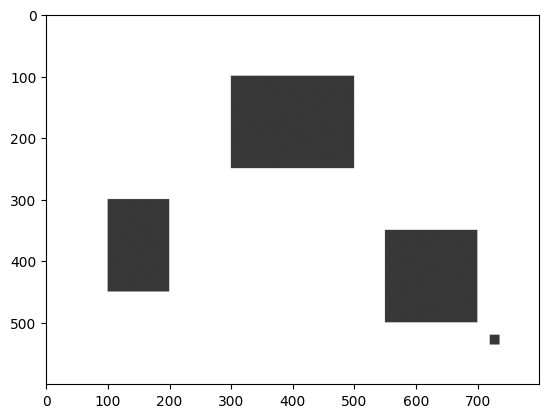

Collision


In [21]:
env = ChopperScape()

N_EPISODES = 1
MAX_ITERS = 500
SHOW_POI = False
resul_list = []
r_list = []

for i in range(N_EPISODES):
    state = env.reset()
    total_r = 0
    for i in range(MAX_ITERS):
        state = torch.FloatTensor(state).to(device)
        action = actor(state)
        next_state, reward, done, arrived = env.step(
            action.detach().cpu().numpy()
        )
        state = next_state
        total_r += reward
        clear_output(wait=True)
        env.render(show_poi=SHOW_POI)

        if arrived:
            print("Arrived!!!")
            resul_list.append("Arrived!!!")
            break
        if done:
            print("Collision")
            resul_list.append("Collision")
            break

    r_list.append(total_r)

### Анализ параметров Heuristics calculation function для нашей карты



100%|██████████| 600/600 [00:17<00:00, 35.18it/s]


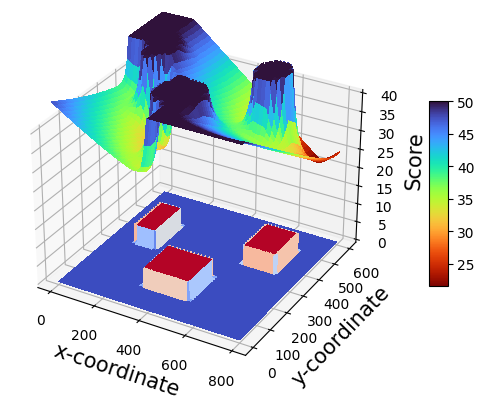

In [12]:
# Heuristics calculation function for a single point
def calculate_heuristic_score(
    x, y, dist_o, dist_g, dist_l1, dist_l2, map, kernel_size
):
    d1 = (
        np.tanh(np.exp((dist_o / dist_l1) ** 2) / exp((dist_l2 / dist_l1) ** 2))
        * dist_l2
    )
    d2 = dist_g

    point_information = 0
    left = max(0, x - int(kernel_size / 2))
    right = min(len(map), x + int(kernel_size / 2))
    top = max(0, y - int(kernel_size / 2))
    bottom = min(len(map[0]), y + int(kernel_size / 2))
    point_information = np.sum(map[left:right, top:bottom])
    count = (right - left) * (bottom - top)
    I = min(50, exp(point_information / count))

    return d1 + d2 + I


"""Parameters"""
dist_l1 = 5  # Inner distance limit for local heuristics discount
dist_l2 = 20  # Outer distance limit for local heuristics discount
goalX = 720  # Distance to the goal on X axis
goalY = 590  # Distance to the goal on Y axis
originX = 10  # Point of origin on X axis
originY = 10  # Point of origin on Y axis
kernel_size = (
    100  # Kernel size in pixels for map information heuristic calculation
)
m_u = 0  # value of the unknown pixels in the map
m_k = 1  # value of the known pixels in the map
m_o = 5  # value of the obstacle pixels in the map


# Create a figure
fig = plt.figure()
ax = fig.add_subplot(projection="3d")

# Generate example map data
X = np.arange(0, 800, 1)
Y = np.arange(0, 600, 1)
X, Y = np.meshgrid(X, Y)
map = np.ones(X.shape) * m_u
for i in range(350, 500):
    for j in range(550, 700):
        map[i][j] = m_o
for i in range(300, 450):
    for j in range(100, 200):
        map[i][j] = m_o
for i in range(100, 250):
    for j in range(300, 500):
        map[i][j] = m_o


# Create a holder for output data
output = np.zeros(X.shape)

# Calculate a heuristics score for every individual point in map range
for ox in tqdm(range(0, len(map))):
    for oy in range(0, len(map[0])):
        dist_o = (
            np.sqrt((X[ox][oy] - originX) ** 2 + (Y[ox][oy] - originY) ** 2)
            / 20
        )
        dist_g = (
            np.sqrt((X[ox][oy] - goalX) ** 2 + (Y[ox][oy] - goalY) ** 2) / 20
        )
        output[ox][oy] = calculate_heuristic_score(
            ox, oy, dist_o, dist_g, dist_l1, dist_l2, map, kernel_size
        )

# Clip the output values for better visualization
output = np.clip(output, 0, 50)

# Plot the heuristics score and the map
surf = ax.plot_surface(
    X, Y, output, cmap=cm.turbo_r, linewidth=0, antialiased=False
)
surf2 = ax.plot_surface(
    X, Y, map, cmap=cm.coolwarm, linewidth=0, antialiased=False
)

# Customize the z axis
ax.set_zlim(0, 40.0)
ax.set_zlabel("Score", size=15)

# Add a color bar which maps values to colors of the heuristics score
fig.colorbar(surf, shrink=0.5, aspect=10, pad=0.1)
plt.xlabel("x-coordinate", size=15)
plt.ylabel("y-coordinate", size=15)
plt.show()

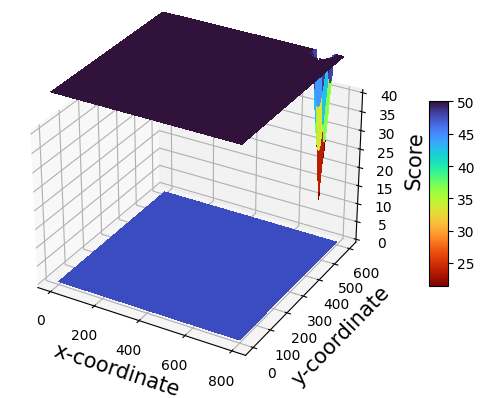

In [ ]:
# Create a figure
fig = plt.figure()
ax = fig.add_subplot(projection="3d")

# Generate example map data
X = np.arange(0, 800, 1)
Y = np.arange(0, 600, 1)
X, Y = np.meshgrid(X, Y)
map = np.ones(X.shape) * m_u
for i in range(350, 500):
    for j in range(550, 700):
        map[i][j] = m_o
for i in range(300, 450):
    for j in range(100, 200):
        map[i][j] = m_o
for i in range(100, 250):
    for j in range(300, 500):
        map[i][j] = m_o


# Create a holder for output data
output = np.zeros(X.shape)

# Calculate a heuristics score for every individual point in map range
for ox in tqdm(range(0, len(map))):
    for oy in range(0, len(map[0])):
        dist_o = (
            np.sqrt((X[ox][oy] - originX) ** 2 + (Y[ox][oy] - originY) ** 2)
            / 20
        )
        dist_g = (
            np.sqrt((X[ox][oy] - goalX) ** 2 + (Y[ox][oy] - goalY) ** 2) / 20
        )
        output[ox][oy] = calculate_heuristic_score(
            ox, oy, dist_o, dist_g, dist_l1, dist_l2, map, kernel_size
        )

# Clip the output values for better visualization
output = np.clip(output, 0, 50)

# Plot the heuristics score and the map
surf = ax.plot_surface(
    X, Y, output, cmap=cm.turbo_r, linewidth=0, antialiased=False
)
surf2 = ax.plot_surface(
    X, Y, map, cmap=cm.coolwarm, linewidth=0, antialiased=False
)

# Customize the z axis
ax.set_zlim(0, 40.0)
ax.set_zlabel("Score", size=15)

# Add a color bar which maps values to colors of the heuristics score
fig.colorbar(surf, shrink=0.5, aspect=10, pad=0.1)
plt.xlabel("x-coordinate", size=15)
plt.ylabel("y-coordinate", size=15)
plt.show()